# 🌙 Project Luna

## Problem Statement

The goal of Project Luna is to analyze gameplay data generated by the Tower of Eternal Eclipse Autobot Simulator.

Luna aims to identify which gameplay variables have the greatest influence on the number of resets required to successfully reach Floor 50.

By learning relationships between combat statistics, progression statistics, and battle outcomes, Luna will later be able to predict the expected number of resets for future player builds and assist in balancing the game.

Note: The Class feature is currently excluded from analysis because all simulations in this dataset use the Archer class. Since the feature has no variation, it provides no predictive value. Once simulations for Knight and Mage are collected, Class will become an important categorical feature for model training.

### Target Variable
- Resets

### Potential Features
- Class
- Level
- EXP
- Floor Reached
- Death Floor
- Battle Turns
- Damage Dealt
- Damage Taken
- Killer Type
- Killer Health Remaining
- Killer Health Percent
- Crits
- Misses
- Normal Attacks
- Strong Attacks
- Special Attacks

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

# Reading csv data

In [3]:
data = pd.read_csv("training_data.csv")
data.head()

,Class,Death Floor,Battle Turns,Killer,Killer Type,Killer Health Remaining,Killer Health Percent,Damage Dealt,Damage Taken,Resets,Level,Floor Reached,EXP,Crits,Misses,Normal Attacks,Strong Attacks,Special Attacks
0,Archer,50,3,THE FORGOTTEN ONE(SHADOW FORM),Shadow Boss,237,47.40,16203,2408,3,19,51,4180,29,8,26,51,25
1,Archer,50,1,THE FORGOTTEN ONE(SHADOW FORM),Shadow Boss,413,82.60,18666,1993,3,19,51,4180,29,8,26,51,25
2,Archer,50,2,THE FORGOTTEN ONE(SHADOW FORM),Shadow Boss,77,15.40,20487,2040,3,19,51,4180,29,8,26,51,25
3,Archer,5,3,THE HOLLOW HUMAN,Boss,4,1.54,777,314,3,18,51,3585,32,6,27,53,25
4,Archer,49,1,Bandits,Normal Enemy,255,78.46,16604,1845,3,18,51,3585,32,6,27,53,25


In [4]:
data.shape

(2832, 18)

In [5]:
data.columns

Index(['Class', 'Death Floor', 'Battle Turns', 'Killer', 'Killer Type',
       'Killer Health Remaining', 'Killer Health Percent', 'Damage Dealt',
       'Damage Taken', 'Resets', 'Level', 'Floor Reached', 'EXP', 'Crits',
       'Misses', 'Normal Attacks', 'Strong Attacks', 'Special Attacks'],
      dtype='str')

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2832 entries, 0 to 2831
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Class                    2832 non-null   str    
 1   Death Floor              2832 non-null   int64  
 2   Battle Turns             2832 non-null   int64  
 3   Killer                   2832 non-null   str    
 4   Killer Type              2832 non-null   str    
 5   Killer Health Remaining  2832 non-null   int64  
 6   Killer Health Percent    2832 non-null   float64
 7   Damage Dealt             2832 non-null   int64  
 8   Damage Taken             2832 non-null   int64  
 9   Resets                   2832 non-null   int64  
 10  Level                    2832 non-null   int64  
 11  Floor Reached            2832 non-null   int64  
 12  EXP                      2832 non-null   int64  
 13  Crits                    2832 non-null   int64  
 14  Misses                   2832 non-n

In [7]:
data.describe()

,Death Floor,Battle Turns,Killer Health Remaining,Killer Health Percent,Damage Dealt,Damage Taken,Resets,Level,Floor Reached,EXP,Crits,Misses,Normal Attacks,Strong Attacks,Special Attacks
count,2832.000000,2832.000000,2832.000000,2832.000000,2832.000000,2832.000000,2832.000000,2832.000000,2832.0,2832.000000,2832.000000,2832.000000,2832.000000,2832.000000,2832.000000
mean,44.076271,2.286723,195.634534,45.553528,16406.023658,1830.462218,3.968927,19.135946,51.0,5443.195975,31.005650,6.211511,26.795551,52.764477,25.453743
std,12.400299,1.220220,142.195636,28.012503,5743.879816,600.435458,2.099037,1.785045,0.0,4656.911665,3.274766,2.325834,2.084121,4.111477,2.082877
min,1.000000,1.000000,1.000000,0.200000,85.000000,100.000000,1.000000,14.000000,51.0,8.000000,22.000000,0.000000,22.000000,43.000000,21.000000
25%,44.000000,1.000000,75.000000,20.575000,15273.000000,1599.000000,2.000000,18.000000,51.0,2262.000000,29.000000,5.000000,25.000000,50.000000,24.000000
50%,50.000000,2.000000,160.000000,43.640000,18339.000000,1953.000000,4.000000,19.000000,51.0,3843.500000,31.000000,6.000000,27.000000,53.000000,25.000000
75%,50.000000,3.000000,330.000000,71.332500,20133.000000,2209.500000,5.000000,20.000000,51.0,7624.250000,33.000000,8.000000,28.000000,55.000000,27.000000
max,51.000000,9.000000,485.000000,97.000000,25569.000000,3374.000000,12.000000,23.000000,51.0,26688.000000,41.000000,14.000000,36.000000,71.000000,34.000000


In [8]:
data.isnull().sum()

Class                      0
Death Floor                0
Battle Turns               0
Killer                     0
Killer Type                0
Killer Health Remaining    0
Killer Health Percent      0
Damage Dealt               0
Damage Taken               0
Resets                     0
Level                      0
Floor Reached              0
EXP                        0
Crits                      0
Misses                     0
Normal Attacks             0
Strong Attacks             0
Special Attacks            0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.describe(include="all")

,Class,Death Floor,Battle Turns,Killer,Killer Type,Killer Health Remaining,Killer Health Percent,Damage Dealt,Damage Taken,Resets,Level,Floor Reached,EXP,Crits,Misses,Normal Attacks,Strong Attacks,Special Attacks
count,2832,2832.000000,2832.000000,2832,2832,2832.000000,2832.000000,2832.000000,2832.000000,2832.000000,2832.000000,2832.0,2832.000000,2832.000000,2832.000000,2832.000000,2832.000000,2832.000000
unique,1,NaN,NaN,13,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Archer,NaN,NaN,THE FORGOTTEN ONE(SHADOW FORM),Shadow Boss,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2832,NaN,NaN,1704,1704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,44.076271,2.286723,NaN,NaN,195.634534,45.553528,16406.023658,1830.462218,3.968927,19.135946,51.0,5443.195975,31.005650,6.211511,26.795551,52.764477,25.453743
std,NaN,12.400299,1.220220,NaN,NaN,142.195636,28.012503,5743.879816,600.435458,2.099037,1.785045,0.0,4656.911665,3.274766,2.325834,2.084121,4.111477,2.082877
min,NaN,1.000000,1.000000,NaN,NaN,1.000000,0.200000,85.000000,100.000000,1.000000,14.000000,51.0,8.000000,22.000000,0.000000,22.000000,43.000000,21.000000
25%,NaN,44.000000,1.000000,NaN,NaN,75.000000,20.575000,15273.000000,1599.000000,2.000000,18.000000,51.0,2262.000000,29.000000,5.000000,25.000000,50.000000,24.000000
50%,NaN,50.000000,2.000000,NaN,NaN,160.000000,43.640000,18339.000000,1953.000000,4.000000,19.000000,51.0,3843.500000,31.000000,6.000000,27.000000,53.000000,25.000000
75%,NaN,50.000000,3.000000,NaN,NaN,330.000000,71.332500,20133.000000,2209.500000,5.000000,20.000000,51.0,7624.250000,33.000000,8.000000,28.000000,55.000000,27.000000


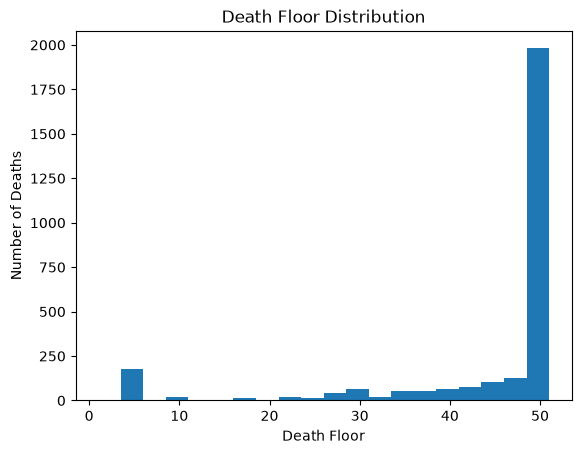

In [11]:
import matplotlib.pyplot as plt

plt.hist(data["Death Floor"], bins=20)
plt.xlabel("Death Floor")
plt.ylabel("Number of Deaths")
plt.title("Death Floor Distribution")
plt.show()

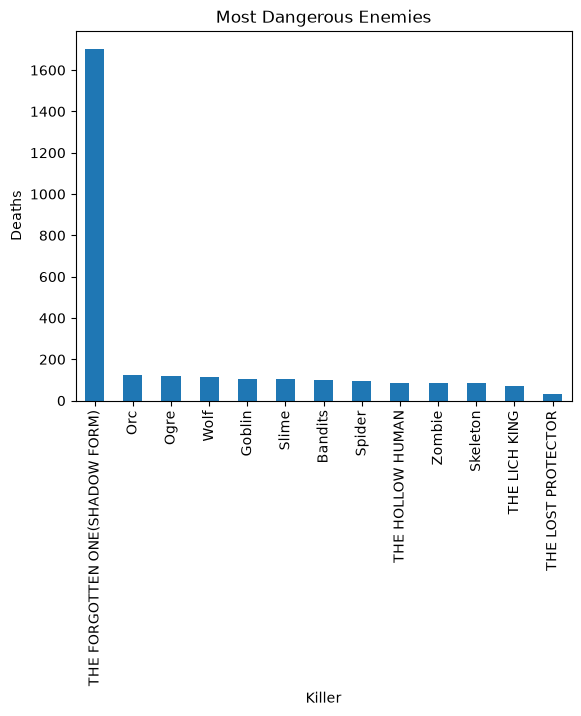

In [12]:
data["Killer"].value_counts().plot(kind="bar")
plt.title("Most Dangerous Enemies")
plt.ylabel("Deaths")
plt.show()

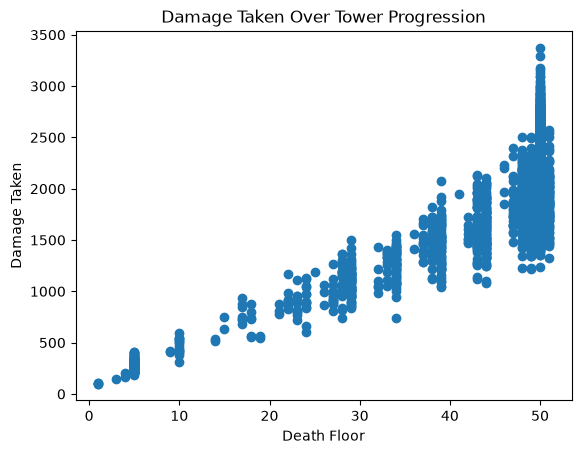

In [13]:
plt.scatter(data["Death Floor"], data["Damage Taken"])
plt.xlabel("Death Floor")
plt.ylabel("Damage Taken")
plt.title("Damage Taken Over Tower Progression")
plt.show()

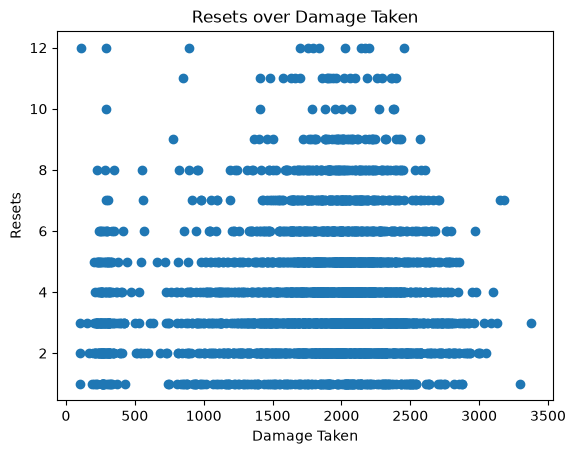

In [14]:
plt.scatter(data["Damage Taken"], data["Resets"])
plt.xlabel("Damage Taken")
plt.ylabel("Resets")
plt.title("Resets over Damage Taken")
plt.show()

## 📊 Damage Taken vs Resets

### Objective
Investigate whether the total amount of damage taken during a run has a relationship with the number of resets required to progress.

### Observation
The scatter plot shows **no strong linear relationship** between **Damage Taken** and **Resets**. Runs with similar amounts of damage often have very different numbers of resets. For example, around **2000–2500 damage taken**, resets range from approximately **1 to 12**.

Most runs are concentrated between **1500–2700 damage taken** and **2–6 resets**, suggesting this is the typical range for the current game balance.

The graph also indicates that high cumulative damage does not necessarily correspond to a high number of resets. Some runs accumulate **3000+ damage taken** while still requiring only a few resets, implying that longer successful runs naturally accumulate more damage without frequent deaths.

### Conclusion
**Damage Taken** alone appears to be a **weak predictor** of **Resets**. The relationship is highly scattered, indicating that resets are influenced by multiple gameplay factors rather than a single variable.

### 🌙 Luna's Observation
This analysis demonstrates that **not every feature is strongly correlated with the target variable**. For Luna to make accurate predictions, additional variables such as **Floor Reached**, **Player Class**, **Battle Turns**, **Critical Hits**, and other combat statistics should also be considered.

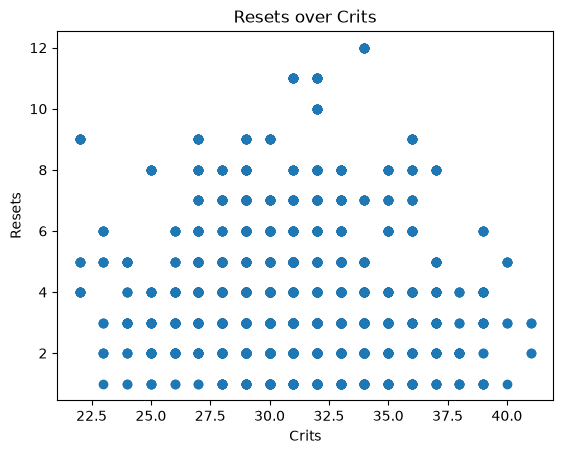

In [15]:
plt.scatter(data["Crits"], data["Resets"])
plt.xlabel("Crits")
plt.ylabel("Resets")
plt.title("Resets over Crits")
plt.show()

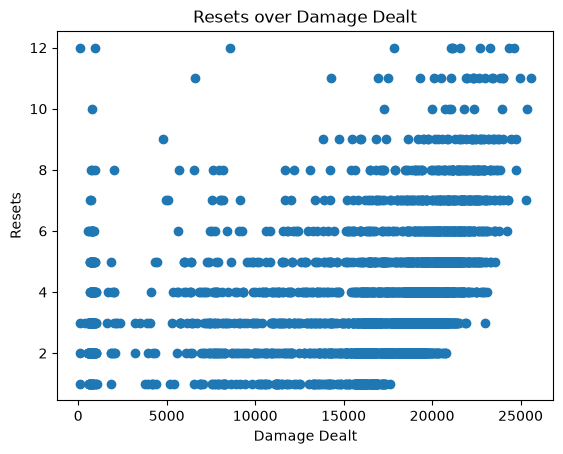

In [16]:
plt.scatter(data["Damage Dealt"], data["Resets"])
plt.xlabel("Damage Dealt")
plt.ylabel("Resets")
plt.title("Resets over Damage Dealt")
plt.show()

## 📊 Damage Dealt vs Resets

### Objective
Investigate whether the total amount of damage dealt during a run has a relationship with the number of resets required to progress.

### Observation
The scatter plot shows a **slight positive relationship** between **Damage Dealt** and **Resets**. As total damage dealt increases, higher reset counts become somewhat more common. However, the data remains widely scattered, indicating that the relationship is relatively weak.

This pattern is expected because longer runs naturally involve more battles, allowing the player to accumulate greater total damage dealt regardless of the number of resets.

### Conclusion
**Damage Dealt** exhibits a **weak positive relationship** with **Resets**, but it is not a strong predictor on its own. Other gameplay variables are likely to have a much greater influence on reset count.

### 🌙 Luna's Observation
This analysis suggests that **Damage Dealt** contains some useful information, but it should be combined with additional features such as **Floor Reached**, **Battle Turns** and **Critical Hits** to improve prediction accuracy.

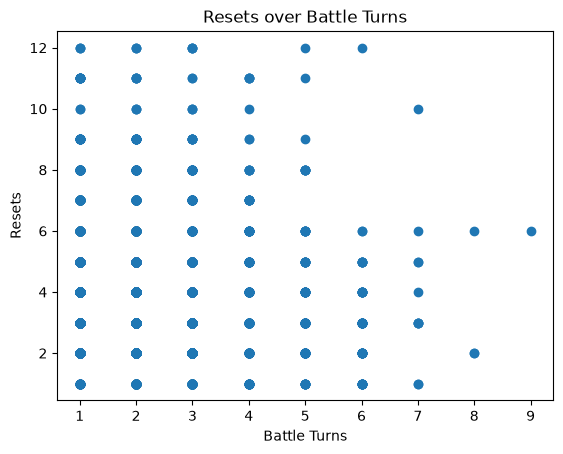

In [17]:
plt.scatter(data["Battle Turns"], data["Resets"])
plt.xlabel("Battle Turns")
plt.ylabel("Resets")
plt.title("Resets over Battle Turns")
plt.show()

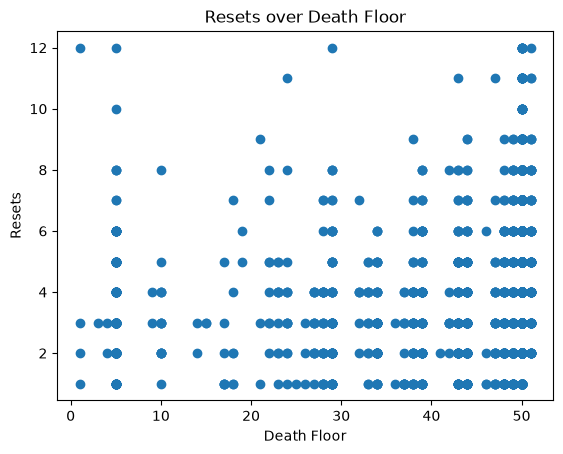

In [18]:
plt.scatter(data["Death Floor"], data["Resets"])
plt.xlabel("Death Floor")
plt.ylabel("Resets")
plt.title("Resets over Death Floor")
plt.show()

## 📊 Death Floor vs Resets

### Objective
Investigate whether the floor on which the player dies is related to the total number of resets required during progression.

### Observation
The scatter plot shows a **very weak positive relationship** between **Death Floor** and **Resets**. As the death floor increases, higher reset counts become slightly more common, but the data remains widely scattered.

Many runs that reached higher floors still had very few resets, while others required many resets before reaching a similar death floor. This indicates considerable variability in player progression.

### Conclusion
**Death Floor** alone is **not a strong predictor** of **Resets**. While a slight positive trend exists, the large spread of data suggests that resets are influenced by multiple gameplay factors rather than progression alone.

### 🌙 Luna's Observation
Although **Death Floor** contains some useful information, it should be combined with additional combat and progression statistics to improve prediction accuracy. This reinforces the idea that predicting player performance requires considering multiple features together rather than relying on a single variable.

In [19]:
data = data.drop(columns=["Class", "Killer", "Floor Reached"])

In [20]:
killer_mapping = {"Normal Enemy": 0,
                 "Boss": 1,
                 "Shadow Boss": 2}
data["Killer Type"] = data["Killer Type"].map(killer_mapping)

In [21]:
data["Killer Type"].value_counts()

Killer Type
2    1704
0     936
1     192
Name: count, dtype: int64

In [22]:
X = data.drop(columns=["Resets"])
y = data["Resets"]

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.ensemble import RandomForestRegressor
luna = RandomForestRegressor(random_state=42)
luna.fit(X_train,y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [25]:
predictions = luna.predict(X_test)
predictions

array([ 5.75,  4.15,  3.03, 10.  ,  7.  ,  1.  ,  5.01,  7.  ,  4.02,
        5.03,  2.  ,  6.  ,  4.03,  1.04,  3.32,  2.91,  4.  ,  2.04,
        4.93,  3.05,  2.04,  8.  ,  1.94,  1.84,  2.08,  4.  ,  4.12,
        2.02,  4.23,  5.96,  2.01,  2.21,  4.  ,  6.  ,  9.  ,  3.  ,
        2.  ,  1.01,  7.  ,  2.99,  3.  ,  3.01,  7.  , 11.  ,  8.  ,
        2.  ,  2.04,  4.94,  7.99,  3.03,  9.  ,  2.03,  5.96,  3.01,
        7.99,  4.45,  5.01, 10.  ,  5.  ,  4.11,  9.  ,  5.96,  2.07,
        3.  ,  6.  ,  2.38,  2.13,  7.02,  3.12,  4.92,  7.  ,  7.  ,
        7.  ,  5.02,  4.43,  1.15,  1.  ,  3.06,  2.94,  3.  ,  6.  ,
        2.02,  8.  ,  1.81,  3.04,  2.  ,  1.82,  3.17,  3.  ,  2.24,
        1.4 ,  2.01,  1.01,  4.06,  4.16,  4.  ,  7.  ,  3.13,  4.95,
        4.02,  5.19,  3.  ,  3.  ,  1.39,  3.29,  3.  ,  7.99,  1.99,
        3.99,  4.92,  3.09,  6.  ,  8.  ,  3.02,  3.  ,  9.  ,  2.12,
        6.  ,  4.07,  2.02,  7.  ,  2.  ,  2.55,  5.06,  5.  ,  3.29,
        2.69,  3.01,

In [26]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,predictions)
print(f"MEAN ABSUTE ERROR: {mae}")

MEAN ABSUTE ERROR: 0.09232804232804229


In [27]:
len(data)

2832

In [28]:
X.columns

Index(['Death Floor', 'Battle Turns', 'Killer Type', 'Killer Health Remaining',
       'Killer Health Percent', 'Damage Dealt', 'Damage Taken', 'Level', 'EXP',
       'Crits', 'Misses', 'Normal Attacks', 'Strong Attacks',
       'Special Attacks'],
      dtype='str')

In [29]:
predictions[:10]


array([ 5.75,  4.15,  3.03, 10.  ,  7.  ,  1.  ,  5.01,  7.  ,  4.02,
        5.03])

In [30]:
y_test[:10]

2727     6
2778     4
1146     3
1110    10
196      7
1837     1
322      5
1613     7
2250     4
2488     5
Name: Resets, dtype: int64

📝 Observation

Luna V1 achieved an MAE of approximately 0.09 resets, indicating extremely accurate predictions on the test set.

⚠️ Limitation

Since the dataset contains one row per death, multiple rows originate from the same simulation. A random train-test split may therefore place deaths from the same run into both the training and testing sets. This likely makes the prediction task easier and may overestimate the model's true performance.

🔮 Future Improvement

For Luna V2, restructure the dataset so that one row represents one complete simulation rather than one death. Perform the train-test split at the simulation level to better evaluate the model's ability to generalize to entirely unseen runs.

In [31]:
luna.feature_importances_

array([1.52679687e-03, 3.36874730e-04, 6.53279765e-05, 1.12083778e-03,
       9.29197633e-04, 2.48741222e-03, 5.16050562e-03, 9.31931933e-01,
       4.84654582e-02, 3.25477181e-03, 2.18350506e-03, 6.81162574e-04,
       1.00403296e-03, 8.52183221e-04])

In [32]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": luna.feature_importances_
})

In [33]:
importance

,Feature,Importance
0,Death Floor,0.001527
1,Battle Turns,0.000337
2,Killer Type,0.000065
3,Killer Health Remaining,0.001121
4,Killer Health Percent,0.000929
5,Damage Dealt,0.002487
6,Damage Taken,0.005161
7,Level,0.931932
8,EXP,0.048465
9,Crits,0.003255


In [34]:
luna_v1_mae = mae
luna_v1_importance = importance

# 🌙 Luna V1 - Progression Predictor

Goal:
Predict player resets using all available gameplay statistics.

Observation:
Level was the dominant feature (93% importance),
suggesting the model relied heavily on progression data.

# 🌙 Luna V2 - Combat Balance Predictor

Goal:
Predict resets based mainly on combat performance,
removing progression-related features.

In [35]:
X_v2 = X.drop(columns=["Level", "EXP"])
X_v2

,Death Floor,Battle Turns,Killer Type,Killer Health Remaining,Killer Health Percent,Damage Dealt,Damage Taken,Crits,Misses,Normal Attacks,Strong Attacks,Special Attacks
0,50,3,2,237,47.40,16203,2408,29,8,26,51,25
1,50,1,2,413,82.60,18666,1993,29,8,26,51,25
2,50,2,2,77,15.40,20487,2040,29,8,26,51,25
3,5,3,1,4,1.54,777,314,32,6,27,53,25
4,49,1,0,255,78.46,16604,1845,32,6,27,53,25
...,...,...,...,...,...,...,...,...,...,...,...,...
2827,50,1,2,412,82.40,17657,1811,27,9,30,59,28
2828,17,4,0,20,12.12,3928,686,30,4,29,56,27
2829,49,1,0,235,74.60,17648,1822,30,4,29,56,27
2830,49,1,0,299,89.25,16001,1961,30,8,28,56,27


In [36]:
X_v2_train, X_v2_test, y_v2_train, y_v2_test = train_test_split(
    X_v2,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
luna_v2 = RandomForestRegressor(random_state=42)

In [38]:
luna_v2.fit(X_v2_train,y_v2_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [39]:
predictions_v2 = luna_v2.predict(X_v2_test)


In [40]:
mae_v2 = mean_absolute_error(y_v2_test,predictions_v2)
mae_v2

1.165379188712522

In [41]:
importance_v2 = pd.DataFrame({
    "Feature": X_v2.columns,
    "Importance": luna_v2.feature_importances_
})

importance_v2 = importance_v2.sort_values(
    by="Importance",
    ascending=False
)

importance_v2

,Feature,Importance
5,Damage Dealt,0.383997
7,Crits,0.099217
6,Damage Taken,0.085729
11,Special Attacks,0.080814
8,Misses,0.076600
10,Strong Attacks,0.069148
4,Killer Health Percent,0.059166
3,Killer Health Remaining,0.058196
9,Normal Attacks,0.045189
1,Battle Turns,0.023744
